In [26]:
import numpy as np
from astropy.table import Table
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
import pickle

from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(70,0.3,0.7)

import sys
sys.path.insert(0,'../g3code/')
from g3misc import *

def multf_model(logN, a, b):
    return a*logN + b

def bperp_theoretical(delta, Om):
    return ( 3 / (4*np.pi*(delta/Om)+1))**(1/3.)

In [27]:
shark = Table.read('../catalogs/waves_g3_groups.fits').to_pandas()
shark_observed = shark[shark.grpid > 0]

# Number density

In [33]:
wide_sv1_sel = (shark_observed.subvol==b'wide') | (shark_observed.subvol==b'deep_sv1')
lowz = shark_observed[wide_sv1_sel]
sv2up = shark_observed[~wide_sv1_sel]

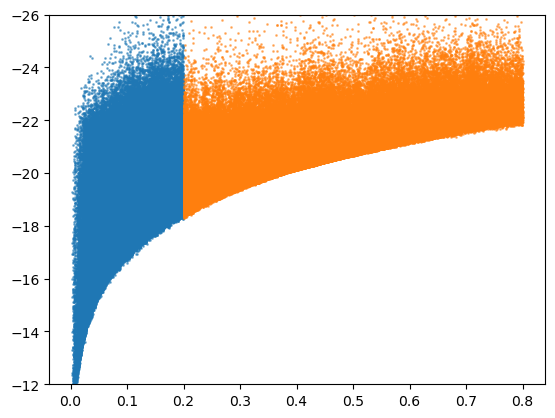

In [36]:
plt.figure()
plt.scatter(lowz.redshift_observed, lowz.mag_abs_r_SDSS, s=1, alpha=0.5)
plt.scatter(sv2up.redshift_observed, sv2up.mag_abs_r_SDSS, s=1, alpha=0.5)
plt.ylim(-12,-26)
plt.show()

# theoretical LL

In [22]:
zz = np.linspace(0,1,1000)

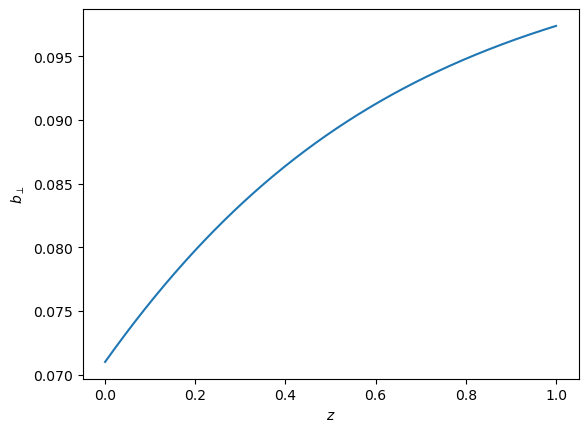

In [23]:
plt.figure()
plt.plot(zz, bperp(200,cosmo.Om(zz)))
plt.xlabel('$z$')
plt.ylabel(r'$b_{\perp}$')
plt.show()